# Pennsylvania Severe Weather Atlas
## Notebook 05 — Event Magnitudes and Reported Impacts

### Purpose

Examine the magnitudes, tornado ratings, and reported impacts in our prepared Pennsylvania dataset for 2011–2025, with a closer look at Lehigh and Northampton counties.

### Notebook goals

1. Examine hail sizes and thunderstorm wind magnitudes, including estimated and measured wind reports.
2. Summarize tornado ratings.
3. Audit and summarize reported injuries, fatalities, property damage, and crop damage.
4. Compare statewide findings with the Lehigh Valley.

Our unit of analysis remains a reported event record. We will check missing values and units before interpreting impact totals.

### Imports and environment check

The next cell loads our analysis tools and displays the Python interpreter used by this notebook.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("Virtual environment:", sys.prefix != sys.base_prefix)
print("Notebook 5 imports loaded successfully.")

Python: 3.13.5
Interpreter: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\.venv\Scripts\python.exe
Virtual environment: True
Notebook 5 imports loaded successfully.


### Environment check

Notebook 5 is using Python 3.13.5 from the project's `.venv` environment. All required imports loaded successfully.

## Loading the prepared event records

We will load `pa_focus_events_2011_2025.csv`, which contains our Pennsylvania focus records and the Lehigh Valley flag.

Property and crop damage fields will be loaded as text so we can inspect their formatting before converting them into numeric amounts.

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_PATHS = {
    "processed": PROJECT_ROOT / "data" / "processed",
    "figures": PROJECT_ROOT / "reports" / "figures",
    "tables": PROJECT_ROOT / "reports" / "tables",
}

FOCUS_EVENT_TYPES = ["Thunderstorm Wind", "Hail", "Tornado"]

dataset_path = (
    PROJECT_PATHS["processed"] / "pa_focus_events_2011_2025.csv"
)

pa_focus_events = pd.read_csv(
    dataset_path,
    dtype={
        "county_fips": "string",
        "is_lehigh_valley": "boolean",
        "hail_ge_1in": "boolean",
        "wind_ge_50kt": "boolean",
        "DAMAGE_PROPERTY": "string",
        "DAMAGE_CROPS": "string",
    },
    parse_dates=["begin_datetime"],
    low_memory=False,
)

print("Project root:", PROJECT_ROOT)
print(f"Rows: {len(pa_focus_events):,}")
print("Columns:", pa_focus_events.shape[1])
print(
    "Year range:",
    pa_focus_events["event_year"].min(),
    "to",
    pa_focus_events["event_year"].max(),
)
print(
    f"Lehigh Valley records: "
    f"{int(pa_focus_events['is_lehigh_valley'].sum()):,}"
)

event_counts = (
    pa_focus_events["EVENT_TYPE"]
    .value_counts()
    .reindex(FOCUS_EVENT_TYPES, fill_value=0)
    .rename_axis("event_type")
    .reset_index(name="record_count")
)

event_counts

Project root: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas
Rows: 15,399
Columns: 60
Year range: 2011 to 2025
Lehigh Valley records: 564


,event_type,record_count
0,Thunderstorm Wind,12630
1,Hail,2441
2,Tornado,328


### Dataset loaded

The dataset contains 15,399 records and 60 columns covering 2011–2025, including 564 Lehigh Valley records.

The event-type totals match our earlier notebooks: 12,630 thunderstorm wind records, 2,441 hail records, and 328 tornado records.

## Hail size distribution

We will count reports at each recorded hail size, measured in inches, for Pennsylvania and the Lehigh Valley.

Percentages use each region's own total hail records. This lets us compare their size distributions despite different sample sizes. The Lehigh Valley is included within the statewide dataset.

All recorded hail sizes remain included, including those below our 1-inch comparison threshold.

In [3]:
hail_records = pa_focus_events.loc[
    pa_focus_events["EVENT_TYPE"].eq("Hail")
].copy()

hail_records["hail_inches"] = pd.to_numeric(
    hail_records["MAGNITUDE"], errors="raise"
)

local_hail_records = hail_records.loc[
    hail_records["is_lehigh_valley"]
].copy()

hail_size_summary = (
    pd.DataFrame({
        "pa_records": hail_records["hail_inches"].value_counts(
            dropna=False
        ),
        "lehigh_valley_records": (
            local_hail_records["hail_inches"].value_counts(dropna=False)
        ),
    })
    .fillna(0)
    .astype(int)
    .sort_index()
    .rename_axis("hail_inches")
    .reset_index()
)

hail_size_summary["pa_percent"] = (
    hail_size_summary["pa_records"] / len(hail_records) * 100
).round(2)

hail_size_summary["lehigh_valley_percent"] = (
    hail_size_summary["lehigh_valley_records"]
    / len(local_hail_records)
    * 100
).round(2)

print(f"Pennsylvania hail records: {len(hail_records):,}")
print(f"Lehigh Valley hail records: {len(local_hail_records):,}")

hail_size_summary

Pennsylvania hail records: 2,441
Lehigh Valley hail records: 93


,hail_inches,pa_records,lehigh_valley_records,pa_percent,lehigh_valley_percent
0,0.75,468,33,19.17,35.48
1,0.80,2,0,0.08,0.00
2,0.88,339,9,13.89,9.68
3,1.00,1059,35,43.38,37.63
4,1.25,193,7,7.91,7.53
5,1.50,122,3,5.00,3.23
6,1.75,192,5,7.87,5.38
7,2.00,41,1,1.68,1.08
8,2.25,3,0,0.12,0.00
9,2.50,12,0,0.49,0.00


### Hail size findings

One-inch hail accounts for 1,059 statewide records (43.38%) and 35 Lehigh Valley records (37.63%).

The Lehigh Valley has a larger share of 0.75-inch reports: 35.48%, compared with 19.17% statewide.

The largest recorded size is 4 inches statewide and 2 inches in the Lehigh Valley, each represented by one record. These maxima describe individual reports within our dataset.

## Visualizing hail size distributions

Paired horizontal bars will compare the percentage of hail records at each reported size.

Each region uses its own hail-record total as the denominator. The legend includes sample sizes: 2,441 statewide records and 93 Lehigh Valley records.

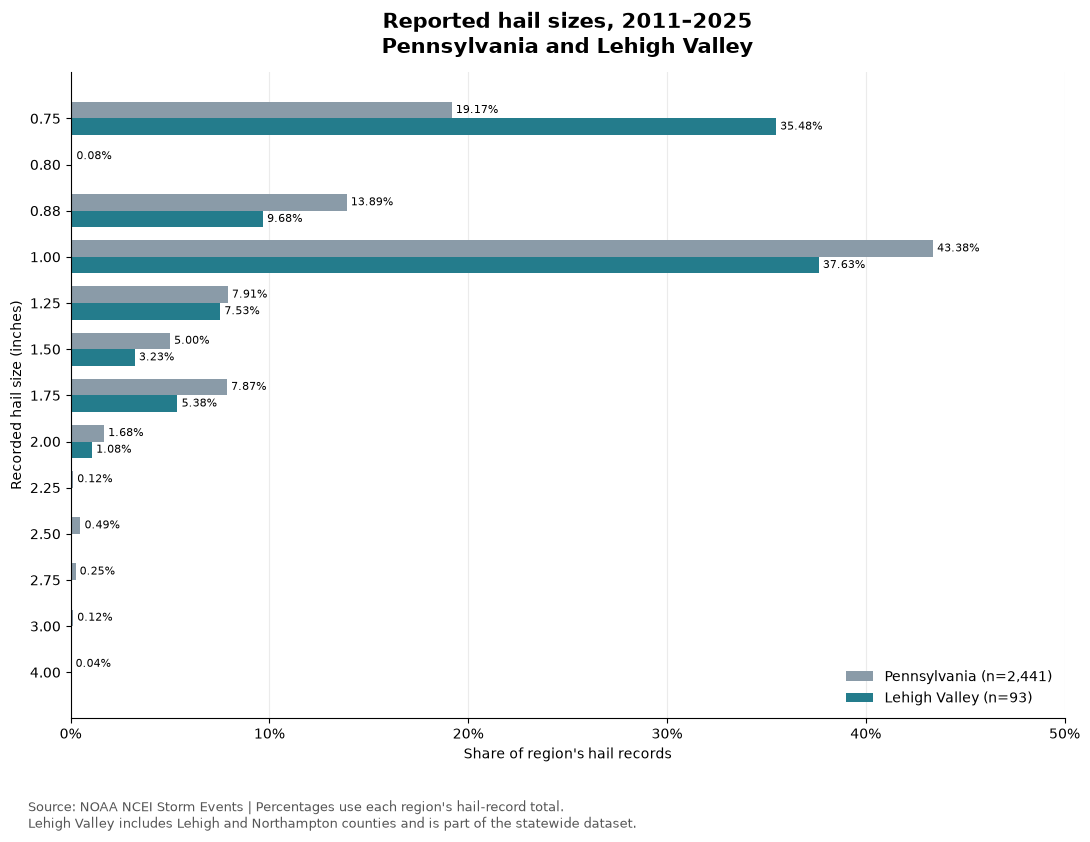

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_lehigh_valley_hail_size_distribution_2011_2025.png


In [4]:
pa_hail_percent = (
    hail_size_summary["pa_records"] / len(hail_records) * 100
)
local_hail_percent = (
    hail_size_summary["lehigh_valley_records"]
    / len(local_hail_records)
    * 100
)

positions = np.arange(len(hail_size_summary))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(11, 8.5), facecolor="white")

pa_bars = ax.barh(
    positions - bar_height / 2,
    pa_hail_percent,
    height=bar_height,
    color="#8A9BA8",
    label=f"Pennsylvania (n={len(hail_records):,})",
)

local_bars = ax.barh(
    positions + bar_height / 2,
    local_hail_percent,
    height=bar_height,
    color="#247C8C",
    label=f"Lehigh Valley (n={len(local_hail_records):,})",
)

for bars, percentages in [
    (pa_bars, pa_hail_percent),
    (local_bars, local_hail_percent),
]:
    ax.bar_label(
        bars,
        labels=[
            f"{value:.2f}%" if value > 0 else ""
            for value in percentages
        ],
        padding=3,
        fontsize=8,
    )

ax.set_yticks(
    positions,
    labels=[
        f"{size:.2f}" for size in hail_size_summary["hail_inches"]
    ],
)
ax.invert_yaxis()

ax.set_xlim(0, 50)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_xlabel("Share of region's hail records")
ax.set_ylabel("Recorded hail size (inches)")
ax.set_title(
    "Reported hail sizes, 2011–2025\nPennsylvania and Lehigh Valley",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right", frameon=False)
sns.despine(ax=ax)

fig.text(
    0.03, 0.02,
    "Source: NOAA NCEI Storm Events | Percentages use each region's hail-record total.\n"
    "Lehigh Valley includes Lehigh and Northampton counties and is part of the statewide dataset.",
    fontsize=9,
    color="#555555",
)

fig.tight_layout(rect=(0, 0.08, 1, 1))

chart_path = (
    PROJECT_PATHS["figures"]
    / "pa_lehigh_valley_hail_size_distribution_2011_2025.png"
)

fig.savefig(chart_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved chart:", chart_path)

### Reading the hail comparison

The 0.75-inch bars illustrate the importance of the denominator: 33 of 93 Lehigh Valley records represent 35.48%, while 468 of 2,441 statewide records represent 19.17%.

One-inch hail is the most common recorded size in both regions. Reports at larger sizes form a much smaller share of each sample.

## Wind magnitudes and reporting types

Wind magnitudes are recorded in knots. We will summarize estimated gusts (`EG`) and measured gusts (`MG`) for Pennsylvania and the Lehigh Valley.

For each group, we will calculate its record count, percentage of that region's wind records, median, 95th percentile, and maximum magnitude.

The 95th percentile helps describe the upper portion of the distribution alongside the single largest recorded value.

In [5]:
wind_records = pa_focus_events.loc[
    pa_focus_events["EVENT_TYPE"].eq("Thunderstorm Wind")
].copy()

wind_records["wind_knots"] = pd.to_numeric(
    wind_records["MAGNITUDE"], errors="raise"
)

wind_records["reporting_type"] = wind_records["MAGNITUDE_TYPE"].replace({
    "EG": "Estimated gust",
    "MG": "Measured gust",
})

local_wind_records = wind_records.loc[
    wind_records["is_lehigh_valley"]
].copy()

wind_summaries = []

for region, records in [
    ("Pennsylvania", wind_records),
    ("Lehigh Valley", local_wind_records),
]:
    summary = (
        records.groupby("reporting_type", dropna=False)["wind_knots"]
        .agg(
            records="size",
            median_knots="median",
            p95_knots=lambda values: values.quantile(0.95),
            maximum_knots="max",
        )
        .reset_index()
    )

    summary.insert(0, "region", region)
    summary.insert(
        3,
        "percent_of_region_wind",
        summary["records"] / len(records) * 100,
    )

    wind_summaries.append(summary)

wind_magnitude_summary = pd.concat(
    wind_summaries, ignore_index=True
).round(2)

print(f"Pennsylvania wind records: {len(wind_records):,}")
print(f"Lehigh Valley wind records: {len(local_wind_records):,}")

wind_magnitude_summary

Pennsylvania wind records: 12,630
Lehigh Valley wind records: 464


,region,reporting_type,records,percent_of_region_wind,median_knots,p95_knots,maximum_knots
0,Pennsylvania,Estimated gust,12326,97.59,50.0,60.00,104.0
1,Pennsylvania,Measured gust,304,2.41,54.0,65.85,77.0
2,Lehigh Valley,Estimated gust,441,95.04,50.0,56.00,70.0
3,Lehigh Valley,Measured gust,23,4.96,53.0,58.80,59.0


### Wind reporting findings

Estimated gusts account for 97.59% of statewide wind records and 95.04% of Lehigh Valley wind records. Their median magnitude is 50 knots in both regions.

The statewide maximum is 104 knots among estimated reports and 77 knots among measured reports. Local maxima are 70 and 59 knots, respectively.

The measured groups contain 304 statewide records and only 23 Lehigh Valley records, so their sample sizes remain important when interpreting the distributions.

## Comparing wind magnitude distributions

An empirical cumulative distribution shows the percentage of a group's records at or below each wind magnitude.

Each region will have separate curves for estimated and measured gusts, with sample sizes in the legends. Both panels use the same axes.

The dotted vertical line marks our 50-knot comparison threshold.

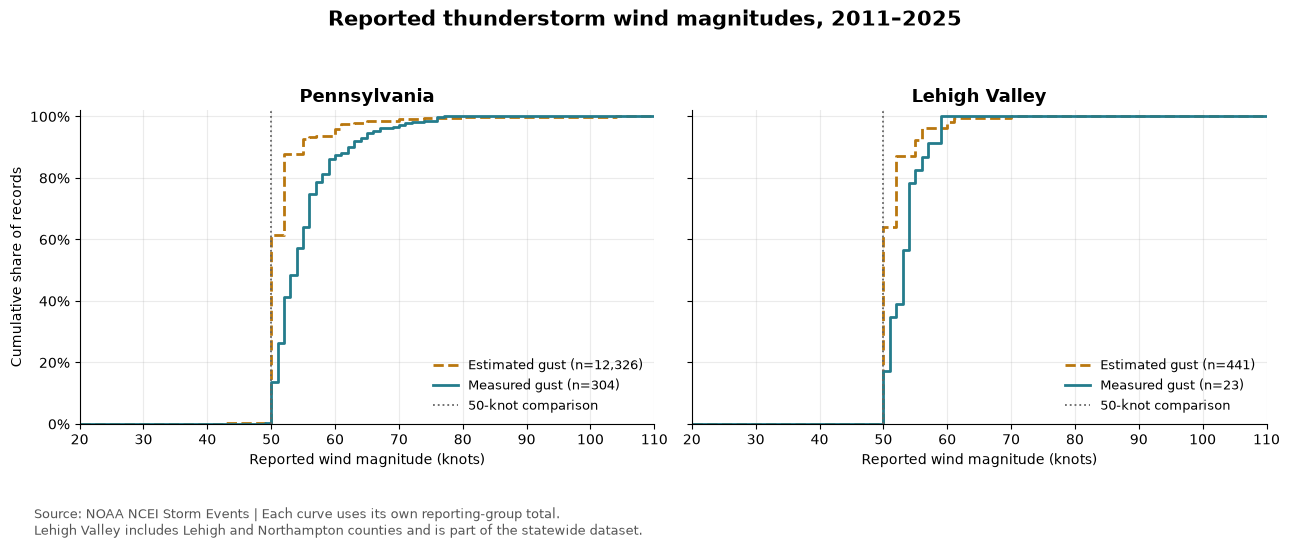

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_lehigh_valley_wind_ecdf_2011_2025.png


In [7]:
wind_x_min = 10 * np.floor(wind_records["wind_knots"].min() / 10)
wind_x_max = 10 * np.ceil(wind_records["wind_knots"].max() / 10)

reporting_styles = {
    "Estimated gust": ("#B9770E", "--"),
    "Measured gust": ("#247C8C", "-"),
}

fig, axes = plt.subplots(
    1, 2, figsize=(13, 5.5),
    sharex=True, sharey=True, facecolor="white"
)

for ax, (region, records) in zip(
    axes,
    [
        ("Pennsylvania", wind_records),
        ("Lehigh Valley", local_wind_records),
    ],
):
    for reporting_type, (color, line_style) in reporting_styles.items():
        frequencies = (
            records.loc[
                records["reporting_type"].eq(reporting_type),
                "wind_knots",
            ]
            .value_counts()
            .sort_index()
        )

        group_total = int(frequencies.sum())
        cumulative_share = frequencies.cumsum() / group_total

        ax.step(
            np.r_[wind_x_min, frequencies.index.to_numpy(), wind_x_max],
            np.r_[0, cumulative_share.to_numpy(), 1],
            where="post",
            color=color,
            linestyle=line_style,
            linewidth=2,
            label=f"{reporting_type} (n={group_total:,})",
        )

    ax.axvline(
        50, color="#666666", linestyle=":", linewidth=1.3,
        label="50-knot comparison"
    )
    ax.set_title(region, fontsize=13, fontweight="bold")
    ax.set_xlabel("Reported wind magnitude (knots)")
    ax.set_xlim(wind_x_min, wind_x_max)
    ax.set_ylim(0, 1.02)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_axisbelow(True)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    sns.despine(ax=ax)

axes[0].set_ylabel("Cumulative share of records")

fig.suptitle(
    "Reported thunderstorm wind magnitudes, 2011–2025",
    fontsize=15, fontweight="bold", y=0.98
)

fig.text(
    0.03, 0.025,
    "Source: NOAA NCEI Storm Events | Each curve uses its own reporting-group total.\n"
    "Lehigh Valley includes Lehigh and Northampton counties and is part of the statewide dataset.",
    fontsize=9, color="#555555"
)

fig.tight_layout(rect=(0, 0.12, 1, 0.93))

chart_path = (
    PROJECT_PATHS["figures"]
    / "pa_lehigh_valley_wind_ecdf_2011_2025.png"
)

fig.savefig(chart_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved chart:", chart_path)

### Reading the wind distributions

Both estimated-gust curves show a large jump at 50 knots, indicating many reports at that recorded magnitude.

The local measured-gust curve has larger steps because it contains only 23 records. Each record contributes approximately 4.35 percentage points; repeated values produce larger jumps.

Once a curve reaches 100%, its horizontal continuation simply maintains the cumulative total across the shared axis range.

## Tornado rating distributions

We will compare tornado rating counts and percentages for Pennsylvania and the Lehigh Valley.

EF0–EF5 will appear in order. EFU will remain a separate category for an unknown rating.

Percentages use each region's own total tornado records. We will also confirm that the rating table accounts for every tornado record.

In [8]:
tornado_records = pa_focus_events.loc[
    pa_focus_events["EVENT_TYPE"].eq("Tornado")
].copy()

tornado_records["tornado_rating"] = (
    tornado_records["TOR_F_SCALE"]
    .astype("string")
    .str.strip()
    .str.upper()
)

local_tornado_records = tornado_records.loc[
    tornado_records["is_lehigh_valley"]
].copy()

TORNADO_RATING_ORDER = [
    "EF0", "EF1", "EF2", "EF3", "EF4", "EF5", "EFU"
]

tornado_rating_summary = (
    pd.DataFrame({
        "pa_records": tornado_records["tornado_rating"].value_counts(
            dropna=False
        ),
        "lehigh_valley_records": (
            local_tornado_records["tornado_rating"]
            .value_counts(dropna=False)
        ),
    })
    .reindex(TORNADO_RATING_ORDER)
    .fillna(0)
    .astype(int)
    .rename_axis("tornado_rating")
    .reset_index()
)

rating_totals_match = (
    tornado_rating_summary["pa_records"].sum() == len(tornado_records)
    and tornado_rating_summary["lehigh_valley_records"].sum()
    == len(local_tornado_records)
)

if not rating_totals_match:
    raise ValueError("Review missing or unexpected tornado rating labels.")

tornado_rating_summary["pa_percent"] = (
    tornado_rating_summary["pa_records"] / len(tornado_records) * 100
).round(2)

tornado_rating_summary["lehigh_valley_percent"] = (
    tornado_rating_summary["lehigh_valley_records"]
    / len(local_tornado_records)
    * 100
).round(2)

print(f"Pennsylvania tornado records: {len(tornado_records):,}")
print(f"Lehigh Valley tornado records: {len(local_tornado_records):,}")
print("Rating totals match both subsets:", rating_totals_match)

tornado_rating_summary

Pennsylvania tornado records: 328
Lehigh Valley tornado records: 7
Rating totals match both subsets: True


,tornado_rating,pa_records,lehigh_valley_records,pa_percent,lehigh_valley_percent
0,EF0,124,3,37.80,42.86
1,EF1,163,4,49.70,57.14
2,EF2,36,0,10.98,0.00
3,EF3,2,0,0.61,0.00
4,EF4,0,0,0.00,0.00
5,EF5,0,0,0.00,0.00
6,EFU,3,0,0.91,0.00


### Tornado rating findings

EF1 is the most common statewide rating, with 163 records (49.70%). Together, EF0 and EF1 account for 287 of 328 records (87.50%).

The Lehigh Valley's seven records consist of three EF0 and four EF1 entries. Each local record represents approximately 14.29 percentage points, so individual records strongly affect the local percentages.

The statewide dataset also contains 36 EF2 records, two EF3 records, and three EFU records with unknown ratings.

## Visualizing tornado ratings

Paired bars will compare each region's percentage of tornado records by rating. Labels above the bars will show the underlying record counts.

EFU will appear after a gap to distinguish unknown ratings from the ordered EF0–EF5 categories.

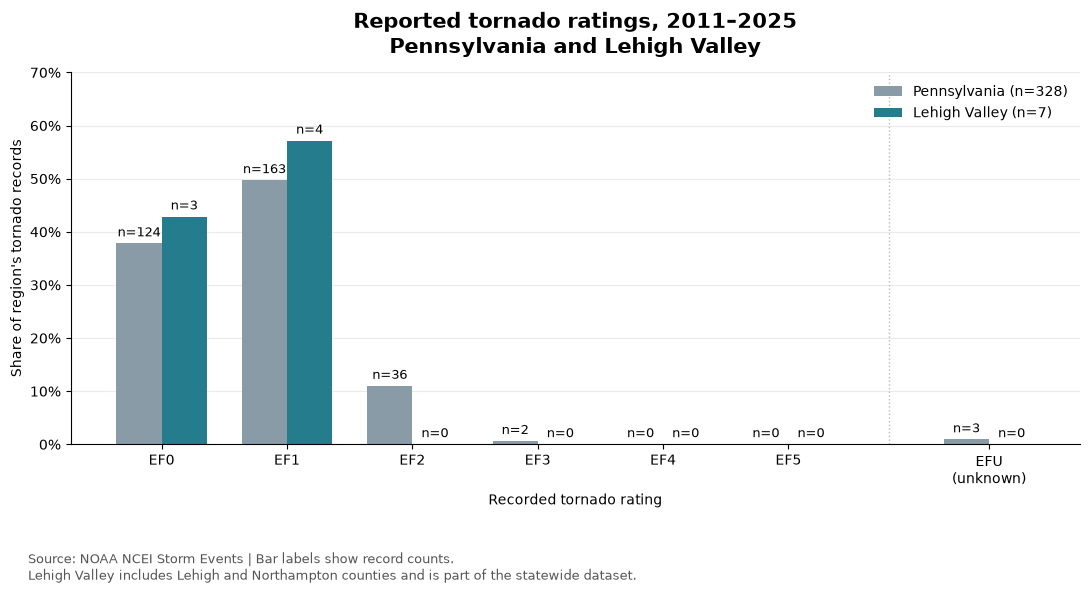

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_lehigh_valley_tornado_ratings_2011_2025.png


In [9]:
pa_rating_share = (
    tornado_rating_summary["pa_records"] / len(tornado_records) * 100
)
local_rating_share = (
    tornado_rating_summary["lehigh_valley_records"]
    / len(local_tornado_records)
    * 100
)

positions = np.arange(len(TORNADO_RATING_ORDER), dtype=float)
positions[-1] += 0.6
bar_width = 0.36

fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")

pa_bars = ax.bar(
    positions - bar_width / 2,
    pa_rating_share,
    width=bar_width,
    color="#8A9BA8",
    label=f"Pennsylvania (n={len(tornado_records):,})",
)

local_bars = ax.bar(
    positions + bar_width / 2,
    local_rating_share,
    width=bar_width,
    color="#247C8C",
    label=f"Lehigh Valley (n={len(local_tornado_records):,})",
)

for bars, counts in [
    (pa_bars, tornado_rating_summary["pa_records"]),
    (local_bars, tornado_rating_summary["lehigh_valley_records"]),
]:
    ax.bar_label(
        bars,
        labels=[f"n={count}" for count in counts],
        padding=3,
        fontsize=9,
    )

ax.axvline(
    (positions[-2] + positions[-1]) / 2,
    color="#BBBBBB",
    linestyle=":",
    linewidth=1,
)

ax.set_xticks(
    positions,
    labels=[
        "EFU\n(unknown)" if rating == "EFU" else rating
        for rating in TORNADO_RATING_ORDER
    ],
)
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_xlabel("Recorded tornado rating")
ax.set_ylabel("Share of region's tornado records")
ax.set_title(
    "Reported tornado ratings, 2011–2025\nPennsylvania and Lehigh Valley",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right", frameon=False)
sns.despine(ax=ax)

fig.text(
    0.03, 0.025,
    "Source: NOAA NCEI Storm Events | Bar labels show record counts.\n"
    "Lehigh Valley includes Lehigh and Northampton counties and is part of the statewide dataset.",
    fontsize=9,
    color="#555555",
)

fig.tight_layout(rect=(0, 0.12, 1, 1))

chart_path = (
    PROJECT_PATHS["figures"]
    / "pa_lehigh_valley_tornado_ratings_2011_2025.png"
)

fig.savefig(chart_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved chart:", chart_path)

### Tornado rating findings

EF1 is the most common statewide rating, with 163 records (49.70%). Together, EF0 and EF1 account for 287 of 328 records (87.50%).

The Lehigh Valley's seven records consist of three EF0 and four EF1 entries. Each local record represents approximately 14.29 percentage points, so individual records strongly affect the local percentages.

The statewide dataset also contains 36 EF2 records, two EF3 records, and three EFU records with unknown ratings.

## Visualizing tornado ratings

Paired bars will compare each region's percentage of tornado records by rating. Labels above the bars will show the underlying record counts.

EFU will appear after a gap to distinguish unknown ratings from the ordered EF0–EF5 categories.

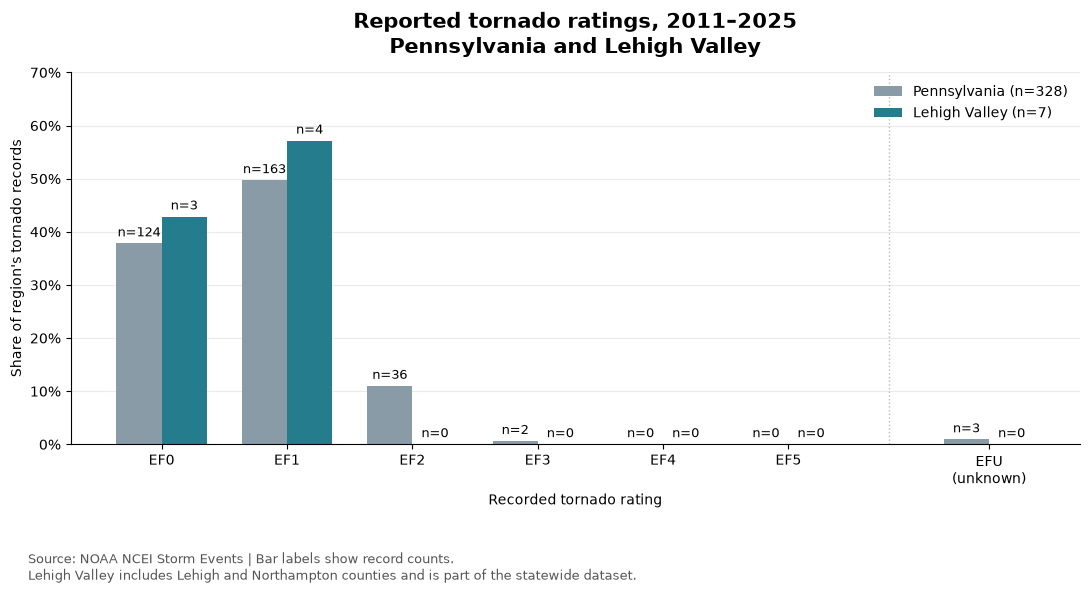

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_lehigh_valley_tornado_ratings_2011_2025.png


In [10]:
pa_rating_share = (
    tornado_rating_summary["pa_records"] / len(tornado_records) * 100
)
local_rating_share = (
    tornado_rating_summary["lehigh_valley_records"]
    / len(local_tornado_records)
    * 100
)

positions = np.arange(len(TORNADO_RATING_ORDER), dtype=float)
positions[-1] += 0.6
bar_width = 0.36

fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")

pa_bars = ax.bar(
    positions - bar_width / 2,
    pa_rating_share,
    width=bar_width,
    color="#8A9BA8",
    label=f"Pennsylvania (n={len(tornado_records):,})",
)

local_bars = ax.bar(
    positions + bar_width / 2,
    local_rating_share,
    width=bar_width,
    color="#247C8C",
    label=f"Lehigh Valley (n={len(local_tornado_records):,})",
)

for bars, counts in [
    (pa_bars, tornado_rating_summary["pa_records"]),
    (local_bars, tornado_rating_summary["lehigh_valley_records"]),
]:
    ax.bar_label(
        bars,
        labels=[f"n={count}" for count in counts],
        padding=3,
        fontsize=9,
    )

ax.axvline(
    (positions[-2] + positions[-1]) / 2,
    color="#BBBBBB",
    linestyle=":",
    linewidth=1,
)

ax.set_xticks(
    positions,
    labels=[
        "EFU\n(unknown)" if rating == "EFU" else rating
        for rating in TORNADO_RATING_ORDER
    ],
)
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_xlabel("Recorded tornado rating")
ax.set_ylabel("Share of region's tornado records")
ax.set_title(
    "Reported tornado ratings, 2011–2025\nPennsylvania and Lehigh Valley",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right", frameon=False)
sns.despine(ax=ax)

fig.text(
    0.03, 0.025,
    "Source: NOAA NCEI Storm Events | Bar labels show record counts.\n"
    "Lehigh Valley includes Lehigh and Northampton counties and is part of the statewide dataset.",
    fontsize=9,
    color="#555555",
)

fig.tight_layout(rect=(0, 0.12, 1, 1))

chart_path = (
    PROJECT_PATHS["figures"]
    / "pa_lehigh_valley_tornado_ratings_2011_2025.png"
)

fig.savefig(chart_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved chart:", chart_path)

## Interpreting the tornado rating chart

EF0 and EF1 account for 287 of Pennsylvania’s 328 tornado records (87.50%). All seven Lehigh Valley records fall into these categories: three EF0 and four EF1.

The local percentages describe a small sample: each record represents approximately 14.29 percentage points.

## Auditing reported injuries and fatalities

Direct injuries and fatalities result from the weather hazard itself or debris moved by it. Indirect impacts result from circumstances caused by the event, such as accidents during storm cleanup.

We will check all four count fields for missing or unreadable entries, negative numbers, and values that are not whole numbers.

The audit’s `positive_records` column counts event records with at least one reported injury or fatality in that field. Missing values remain missing during this check.

In [11]:
IMPACT_COUNT_FIELDS = [
    "INJURIES_DIRECT",
    "INJURIES_INDIRECT",
    "DEATHS_DIRECT",
    "DEATHS_INDIRECT",
]

impact_counts = pa_focus_events[IMPACT_COUNT_FIELDS].apply(
    pd.to_numeric, errors="coerce"
)

impact_count_audit = pd.DataFrame({
    "records": len(impact_counts),
    "missing_or_unreadable": impact_counts.isna().sum(),
    "negative_values": impact_counts.lt(0).sum(),
    "non_whole_values": (
        impact_counts.notna() & impact_counts.mod(1).ne(0)
    ).sum(),
    "zero_records": impact_counts.eq(0).sum(),
    "positive_records": impact_counts.gt(0).sum(),
}).rename_axis("field").reset_index()

impact_count_audit

,field,records,missing_or_unreadable,negative_values,non_whole_values,zero_records,positive_records
0,INJURIES_DIRECT,15399,0,0,0,15317,82
1,INJURIES_INDIRECT,15399,0,0,0,15394,5
2,DEATHS_DIRECT,15399,0,0,0,15382,17
3,DEATHS_INDIRECT,15399,0,0,0,15394,5


## Interpreting the injury and fatality audit

All four fields contain readable, non-negative whole-number counts across all 15,399 records, with no missing values.

Positive counts appear in:

- 82 records for direct injuries.
- 5 records for indirect injuries.
- 17 records for direct fatalities.
- 5 records for indirect fatalities.

These are counts of records containing reported impacts. One record can include multiple people and can appear in more than one category.

## Summarizing reported injuries and fatalities

We will total reported injuries and fatalities by event type for Pennsylvania and the Lehigh Valley, keeping direct and indirect impacts separate.

The `event_records` column shows how many records contribute to each group. Pennsylvania includes the Lehigh Valley, so the regional totals overlap.

In [12]:
impact_records = pa_focus_events[
    ["EVENT_TYPE", "is_lehigh_valley"]
].join(impact_counts)

impact_summaries = []

for region, records in [
    ("Pennsylvania", impact_records),
    (
        "Lehigh Valley",
        impact_records.loc[impact_records["is_lehigh_valley"]],
    ),
]:
    summary = (
        records.groupby("EVENT_TYPE")
        .agg(
            event_records=("EVENT_TYPE", "size"),
            injuries_direct=("INJURIES_DIRECT", "sum"),
            injuries_indirect=("INJURIES_INDIRECT", "sum"),
            deaths_direct=("DEATHS_DIRECT", "sum"),
            deaths_indirect=("DEATHS_INDIRECT", "sum"),
        )
        .reindex(FOCUS_EVENT_TYPES)
        .rename_axis("event_type")
        .reset_index()
    )

    summary.insert(0, "region", region)
    impact_summaries.append(summary)

injury_fatality_summary = pd.concat(
    impact_summaries, ignore_index=True
)

injury_fatality_summary

,region,event_type,event_records,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect
0,Pennsylvania,Thunderstorm Wind,12630,135,7,17,5
1,Pennsylvania,Hail,2441,0,0,0,0
2,Pennsylvania,Tornado,328,70,3,1,0
3,Lehigh Valley,Thunderstorm Wind,464,2,0,0,0
4,Lehigh Valley,Hail,93,0,0,0,0
5,Lehigh Valley,Tornado,7,0,0,0,0


## Interpreting reported injuries and fatalities

Pennsylvania’s focus records contain **215 reported injuries**: 205 direct and 10 indirect. They also contain **23 reported fatalities**: 18 direct and 5 indirect.

Thunderstorm Wind accounts for 142 injuries and 22 fatalities. Tornado accounts for 73 injuries and one fatality. Hail records contain zero reported injuries or fatalities in these fields.

The Lehigh Valley records contain two direct injuries, both associated with Thunderstorm Wind, and zero reported fatalities.

## Visualizing reported injuries and fatalities

We will display Pennsylvania’s injury and fatality counts in separate panels. Each bar combines direct and indirect impacts, distinguished by color.

Labels show the combined totals. Each panel uses its own horizontal scale.

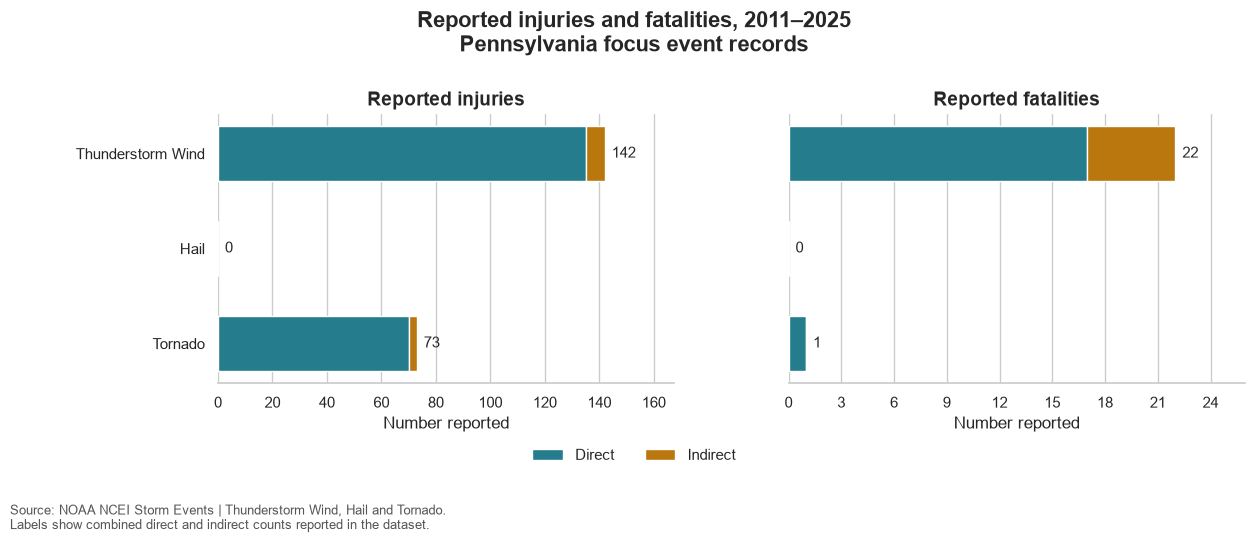

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_reported_injuries_fatalities_2011_2025.png


In [13]:
statewide_impacts = (
    injury_fatality_summary
    .loc[injury_fatality_summary["region"].eq("Pennsylvania")]
    .set_index("event_type")
    .reindex(FOCUS_EVENT_TYPES)
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
positions = np.arange(len(FOCUS_EVENT_TYPES))

for ax, prefix, title in zip(
    axes,
    ["injuries", "deaths"],
    ["Reported injuries", "Reported fatalities"],
):
    direct = statewide_impacts[f"{prefix}_direct"].to_numpy()
    indirect = statewide_impacts[f"{prefix}_indirect"].to_numpy()
    totals = direct + indirect

    ax.barh(
        positions, direct, height=0.58,
        color="#247C8C", label="Direct",
    )
    indirect_bars = ax.barh(
        positions, indirect, left=direct, height=0.58,
        color="#B9770E", label="Indirect",
    )
    ax.bar_label(
        indirect_bars,
        labels=[f"{value:,.0f}" for value in totals],
        padding=5,
        fontsize=11,
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Number reported")
    ax.set_xlim(0, max(1, totals.max() * 1.18))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=True)

axes[0].set_yticks(positions, FOCUS_EVENT_TYPES)
axes[0].invert_yaxis()

fig.suptitle(
    "Reported injuries and fatalities, 2011–2025\n"
    "Pennsylvania focus event records",
    fontsize=16,
    fontweight="bold",
)
fig.legend(
    *axes[0].get_legend_handles_labels(),
    loc="lower center",
    bbox_to_anchor=(0.5, 0.13),
    ncol=2,
    frameon=False,
)
fig.text(
    0.02, 0.035,
    "Source: NOAA NCEI Storm Events | Thunderstorm Wind, Hail and Tornado.\n"
    "Labels show combined direct and indirect counts reported in the dataset.",
    fontsize=9,
    color="#555555",
)
fig.subplots_adjust(
    left=0.18, right=0.97, top=0.79, bottom=0.30, wspace=0.25
)

chart_path = (
    PROJECT_PATHS["figures"]
    / "pa_reported_injuries_fatalities_2011_2025.png"
)
fig.savefig(chart_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved chart:", chart_path)

## Interpreting the injury and fatality chart

The chart shows 142 reported injuries and 22 fatalities for Thunderstorm Wind, compared with 73 injuries and one fatality for Tornado. Hail shows zero in both panels.

Direct impacts account for most of these totals. The panels use different horizontal scales, so compare bar lengths within each panel.

## Auditing property and crop damage formats

Property and crop damage estimates can contain a number followed by a scale suffix:

| Suffix | Dollar multiplier |
| --- | ---: |
| K | 1,000 |
| M | 1,000,000 |
| B | 1,000,000,000 |

Before converting these estimates, we will count missing entries, number-only entries, each recognized suffix, and unrecognized formats.

Missing entries remain missing. An explicit value such as `0.00K` remains distinguishable from a missing estimate.

In [14]:
DAMAGE_FIELDS = ["DAMAGE_PROPERTY", "DAMAGE_CROPS"]

damage_text = (
    pa_focus_events[DAMAGE_FIELDS]
    .astype("string")
    .apply(lambda column: column.str.strip().str.upper())
    .replace("", pd.NA)
)

damage_pattern = r"^(?P<amount>\d+(?:\.\d+)?)(?P<suffix>[KMB]?)$"
damage_format_rows = []

for field in DAMAGE_FIELDS:
    values = damage_text[field]
    parts = values.str.extract(damage_pattern)

    damage_format_rows.append({
        "field": field,
        "records": len(values),
        "missing_or_blank": values.isna().sum(),
        "number_only": parts["suffix"].eq("").sum(),
        "with_K": parts["suffix"].eq("K").sum(),
        "with_M": parts["suffix"].eq("M").sum(),
        "with_B": parts["suffix"].eq("B").sum(),
        "unrecognized": (
            values.notna() & parts["amount"].isna()
        ).sum(),
    })

damage_format_audit = pd.DataFrame(damage_format_rows)

damage_format_audit

,field,records,missing_or_blank,number_only,with_K,with_M,with_B,unrecognized
0,DAMAGE_PROPERTY,15399,2127,0,13255,17,0,0
1,DAMAGE_CROPS,15399,2248,0,13151,0,0,0


## Interpreting the damage format audit

Property damage contains 13,272 populated entries and 2,127 missing entries. Of the populated entries, 13,255 use K and 17 use M.

Crop damage contains 13,151 populated entries and 2,248 missing entries. All populated entries use K.

There are no unrecognized formats. These checks establish how the values are stored; we still need to distinguish explicit zeros from positive damage estimates.

## Converting damage estimates to dollars

We will create numeric property and crop damage columns by multiplying each amount by its suffix multiplier.

Missing estimates remain missing, and explicit zeros remain zero. We will inspect the resulting counts and maximum values before calculating damage totals.

This step converts units without applying an inflation adjustment.

In [15]:
DAMAGE_MULTIPLIERS = {
    "": 1,
    "K": 1_000,
    "M": 1_000_000,
    "B": 1_000_000_000,
}

DAMAGE_USD_COLUMNS = {
    "DAMAGE_PROPERTY": "property_damage_usd",
    "DAMAGE_CROPS": "crop_damage_usd",
}

damage_usd = pd.DataFrame(index=damage_text.index)
damage_conversion_rows = []

for field, output_column in DAMAGE_USD_COLUMNS.items():
    parts = damage_text[field].str.extract(damage_pattern)
    amounts = pd.to_numeric(parts["amount"], errors="raise")
    multipliers = parts["suffix"].map(DAMAGE_MULTIPLIERS)

    values = (amounts * multipliers).astype("Float64")
    damage_usd[output_column] = values

    damage_conversion_rows.append({
        "field": field,
        "non_missing_estimates": values.notna().sum(),
        "missing_estimates": values.isna().sum(),
        "zero_estimates": values.eq(0).sum(),
        "positive_estimates": values.gt(0).sum(),
        "maximum_usd": values.max(),
        "missing_preserved": values.isna().equals(
            damage_text[field].isna()
        ),
    })

damage_conversion_audit = pd.DataFrame(damage_conversion_rows)

damage_conversion_audit

,field,non_missing_estimates,missing_estimates,zero_estimates,positive_estimates,maximum_usd,missing_preserved
0,DAMAGE_PROPERTY,13272,2127,4879,8393,8000000.0,True
1,DAMAGE_CROPS,13151,2248,13010,141,1000000.0,True


## Interpreting the damage conversion

Property damage has 8,393 positive estimates and 4,879 explicit zero estimates, with 2,127 entries remaining missing.

Crop damage has 141 positive estimates and 13,010 explicit zero estimates, with 2,248 entries remaining missing.

The largest estimates in individual records are $8 million for property damage and $1 million for crop damage. Both missing-value checks passed.

## Summarizing reported damage

We will sum available damage estimates by region, event type, and damage category. Counts of missing and positive estimates will accompany each total.

These totals use reported dollars without an inflation adjustment. Missing estimates are excluded from the sums, so the totals describe the available estimates rather than complete economic losses.

A group with entirely missing estimates will retain a missing total. Pennsylvania includes the Lehigh Valley, so the regional totals overlap.

In [16]:
damage_records = pa_focus_events[
    ["EVENT_TYPE", "is_lehigh_valley"]
].join(damage_usd)

damage_summaries = []

for region, records in [
    ("Pennsylvania", damage_records),
    (
        "Lehigh Valley",
        damage_records.loc[damage_records["is_lehigh_valley"]],
    ),
]:
    for damage_type, column in [
        ("Property", "property_damage_usd"),
        ("Crops", "crop_damage_usd"),
    ]:
        summary = (
            records.groupby("EVENT_TYPE")[column]
            .agg(
                event_records="size",
                missing_estimates=lambda values: values.isna().sum(),
                positive_estimates=lambda values: values.gt(0).sum(),
                reported_damage_usd=lambda values: values.sum(min_count=1),
            )
            .reindex(FOCUS_EVENT_TYPES)
            .rename_axis("event_type")
            .reset_index()
        )

        summary.insert(0, "region", region)
        summary.insert(2, "damage_type", damage_type)
        damage_summaries.append(summary)

reported_damage_summary = pd.concat(
    damage_summaries, ignore_index=True
)

reported_damage_summary

,region,event_type,damage_type,event_records,missing_estimates,positive_estimates,reported_damage_usd
0,Pennsylvania,Thunderstorm Wind,Property,12630,1402,8093,139073160.0
1,Pennsylvania,Hail,Property,2441,672,77,3487000.0
2,Pennsylvania,Tornado,Property,328,53,223,60948000.0
3,Pennsylvania,Thunderstorm Wind,Crops,12630,1849,119,1243000.0
4,Pennsylvania,Hail,Crops,2441,340,12,19500.0
5,Pennsylvania,Tornado,Crops,328,59,10,893500.0
6,Lehigh Valley,Thunderstorm Wind,Property,464,145,34,1646000.0
7,Lehigh Valley,Hail,Property,93,16,1,25000.0
8,Lehigh Valley,Tornado,Property,7,3,1,20000.0
9,Lehigh Valley,Thunderstorm Wind,Crops,464,146,0,0.0


## Interpreting reported damage totals

The available estimates sum to:

| Region | Property damage | Crop damage |
| --- | ---: | ---: |
| Pennsylvania | $203,508,160 | $2,156,000 |
| Lehigh Valley | $1,691,000 | $0 |

Thunderstorm Wind contributes the largest reported property damage total in both regions.

The Lehigh Valley’s crop total comes from 398 explicit zero estimates, while another 166 records lack crop damage estimates. This describes the available reports, not proof that crop damage was absent.

## Interpreting reported damage totals

The available estimates sum to:

| Region | Property damage | Crop damage |
| --- | ---: | ---: |
| Pennsylvania | $203,508,160 | $2,156,000 |
| Lehigh Valley | $1,691,000 | $0 |

Thunderstorm Wind contributes the largest reported property damage total in both regions.

The Lehigh Valley’s crop total comes from 398 explicit zero estimates, while another 166 records lack crop damage estimates. This describes the available reports, not proof that crop damage was absent.

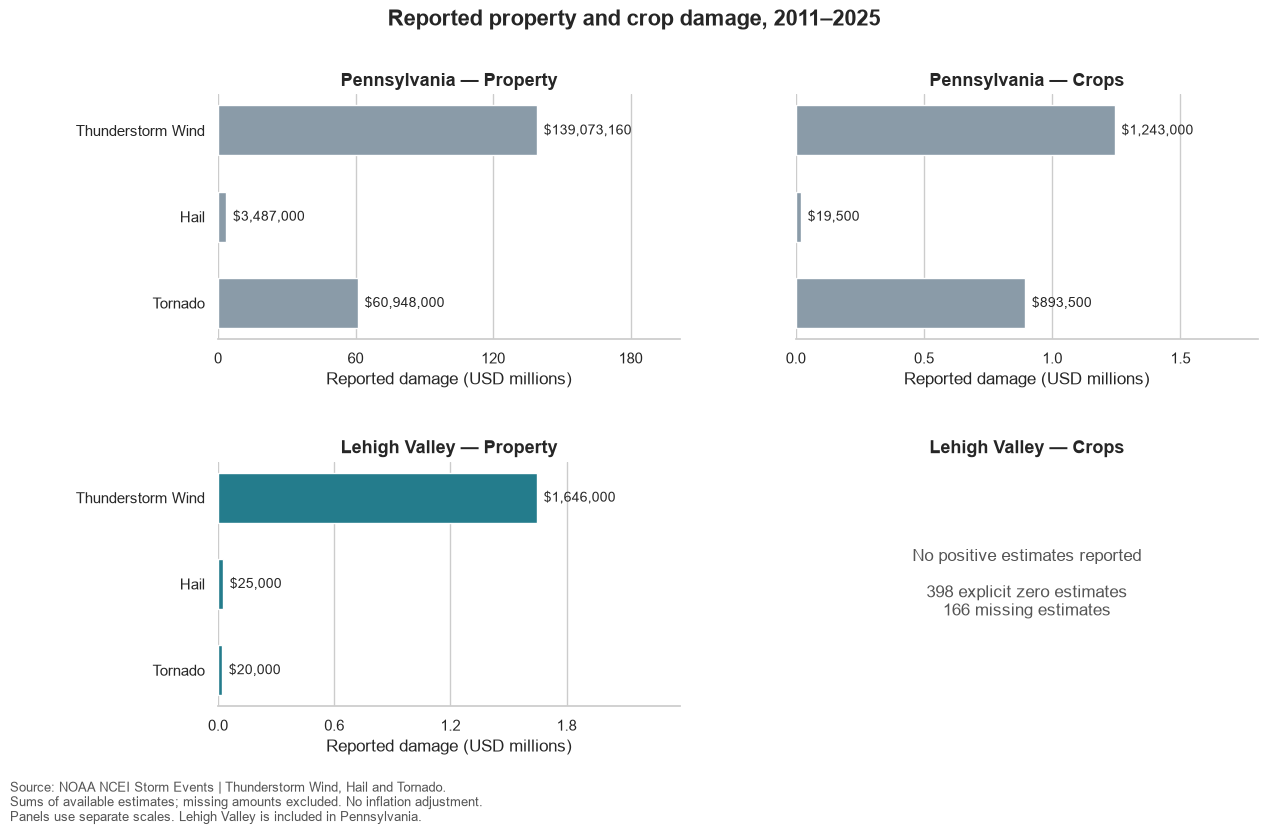

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_lehigh_valley_reported_damage_2011_2025.png


In [17]:
damage_region_colors = {
    "Pennsylvania": "#8A9BA8",
    "Lehigh Valley": "#247C8C",
}

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharey=True)
positions = np.arange(len(FOCUS_EVENT_TYPES))

for row, region in enumerate(["Pennsylvania", "Lehigh Valley"]):
    for col, damage_type in enumerate(["Property", "Crops"]):
        ax = axes[row, col]

        panel = (
            reported_damage_summary.loc[
                reported_damage_summary["region"].eq(region)
                & reported_damage_summary["damage_type"].eq(damage_type)
            ]
            .set_index("event_type")
            .reindex(FOCUS_EVENT_TYPES)
        )

        ax.set_title(
            f"{region} — {damage_type}",
            fontsize=13,
            fontweight="bold",
        )

        if panel["positive_estimates"].sum() == 0:
            missing_count = panel["missing_estimates"].sum()
            zero_count = (
                panel["event_records"]
                - panel["missing_estimates"]
                - panel["positive_estimates"]
            ).sum()

            ax.axis("off")
            ax.text(
                0.5, 0.5,
                "No positive estimates reported\n\n"
                f"{zero_count:,.0f} explicit zero estimates\n"
                f"{missing_count:,.0f} missing estimates",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=12,
                color="#555555",
            )
            continue

        totals = panel["reported_damage_usd"].to_numpy(
            dtype=float, na_value=np.nan
        )
        bars = ax.barh(
            positions,
            totals / 1_000_000,
            height=0.58,
            color=damage_region_colors[region],
        )
        ax.bar_label(
            bars,
            labels=[f"${value:,.0f}" for value in totals],
            padding=5,
            fontsize=10,
        )

        ax.set_xlim(0, np.nanmax(totals) / 1_000_000 * 1.45)
        ax.set_xlabel("Reported damage (USD millions)")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.grid(axis="y", visible=False)
        ax.set_axisbelow(True)
        sns.despine(ax=ax, left=True)

axes[0, 0].set_yticks(positions, FOCUS_EVENT_TYPES)
axes[0, 0].invert_yaxis()

fig.suptitle(
    "Reported property and crop damage, 2011–2025",
    fontsize=16,
    fontweight="bold",
)
fig.text(
    0.02, 0.025,
    "Source: NOAA NCEI Storm Events | Thunderstorm Wind, Hail and Tornado.\n"
    "Sums of available estimates; missing amounts excluded. No inflation adjustment.\n"
    "Panels use separate scales. Lehigh Valley is included in Pennsylvania.",
    fontsize=9,
    color="#555555",
)
fig.subplots_adjust(
    left=0.18, right=0.98, top=0.88, bottom=0.16,
    hspace=0.50, wspace=0.25,
)

chart_path = (
    PROJECT_PATHS["figures"]
    / "pa_lehigh_valley_reported_damage_2011_2025.png"
)
fig.savefig(chart_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved chart:", chart_path)

## Interpreting the reported damage chart

The chart displays these sums of available estimates:

| Region and damage category | Thunderstorm Wind | Hail | Tornado |
| --- | ---: | ---: | ---: |
| Pennsylvania property | $139,073,160 | $3,487,000 | $60,948,000 |
| Pennsylvania crops | $1,243,000 | $19,500 | $893,500 |
| Lehigh Valley property | $1,646,000 | $25,000 | $20,000 |

Thunderstorm Wind contributes the largest reported total in each bar panel.

The Lehigh Valley crop panel shows 398 explicit zero estimates and 166 missing estimates. No positive crop damage estimates appear in the available local records; missing estimates remain unknown.

Each panel uses its own horizontal scale. The dollar amounts are reported estimates without an inflation adjustment, and Pennsylvania’s totals include the Lehigh Valley.

## Saving and verifying Notebook 5 outputs

We will save the summary and audit tables to `reports/tables`, and an enriched dataset containing the numeric property and crop damage columns to `data/processed`.

Each CSV will be reloaded and compared with its in-memory table, checking column order, values, and missing-value locations. Numeric comparisons allow a small floating-point tolerance.

In [18]:
notebook5_tables = {
    "pa_lehigh_valley_hail_sizes": hail_size_summary,
    "pa_lehigh_valley_wind_magnitudes": wind_magnitude_summary,
    "pa_lehigh_valley_tornado_ratings": tornado_rating_summary,
    "pa_injury_fatality_audit": impact_count_audit,
    "pa_lehigh_valley_injuries_fatalities": injury_fatality_summary,
    "pa_damage_format_audit": damage_format_audit,
    "pa_damage_conversion_audit": damage_conversion_audit,
    "pa_lehigh_valley_reported_damage": reported_damage_summary,
}

notebook5_exports = {
    PROJECT_PATHS["tables"] / f"{name}_2011_2025.csv": table
    for name, table in notebook5_tables.items()
}

pa_focus_with_impacts = pa_focus_events.join(damage_usd)
impact_dataset_path = (
    PROJECT_PATHS["processed"]
    / "pa_focus_events_with_impacts_2011_2025.csv"
)
notebook5_exports[impact_dataset_path] = pa_focus_with_impacts

save_check_rows = []

for output_path, table in notebook5_exports.items():
    table.to_csv(output_path, index=False)

    date_columns = (
        ["begin_datetime"] if "begin_datetime" in table.columns else []
    )
    reloaded = pd.read_csv(
        output_path,
        dtype=table.drop(columns=date_columns).dtypes.to_dict(),
        parse_dates=date_columns,
        low_memory=False,
    )

    pd.testing.assert_frame_equal(
        table.reset_index(drop=True),
        reloaded,
        check_dtype=False,
        check_exact=False,
        rtol=1e-12,
        atol=1e-8,
        obj=output_path.name,
    )

    save_check_rows.append({
        "file": output_path.name,
        "saved_rows": len(reloaded),
        "saved_columns": reloaded.shape[1],
        "values_match": True,
    })

notebook5_save_check = pd.DataFrame(save_check_rows)

print("Dataset saved to:", impact_dataset_path)
notebook5_save_check

Dataset saved to: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\data\processed\pa_focus_events_with_impacts_2011_2025.csv


,file,saved_rows,saved_columns,values_match
0,pa_lehigh_valley_hail_sizes_2011_2025.csv,13,5,True
1,pa_lehigh_valley_wind_magnitudes_2011_2025.csv,4,7,True
2,pa_lehigh_valley_tornado_ratings_2011_2025.csv,7,5,True
3,pa_injury_fatality_audit_2011_2025.csv,4,7,True
4,pa_lehigh_valley_injuries_fatalities_2011_2025...,6,7,True
5,pa_damage_format_audit_2011_2025.csv,2,8,True
6,pa_damage_conversion_audit_2011_2025.csv,2,7,True
7,pa_lehigh_valley_reported_damage_2011_2025.csv,12,7,True
8,pa_focus_events_with_impacts_2011_2025.csv,15399,62,True


## Export verification

All eight summary and audit tables and the enriched dataset were saved and reloaded successfully. Column order, values, and missing-value locations matched, allowing a small numeric tolerance.

The enriched dataset contains **15,399 records and 62 columns**, including `property_damage_usd` and `crop_damage_usd`.

## Notebook 5 conclusion

This notebook examined event magnitudes and reported impacts across Pennsylvania and the Lehigh Valley during 2011–2025.

### Main findings

- **Hail:** One inch was the most frequently reported size in both regions.
- **Thunderstorm Wind:** Estimated gusts accounted for 97.59% of statewide wind records and 95.04% of local wind records.
- **Tornado:** EF0 and EF1 accounted for 287 of Pennsylvania’s 328 tornado records and all seven Lehigh Valley tornado records.
- **Injuries and fatalities:** Statewide records contained 215 reported injuries and 23 fatalities, combining direct and indirect impacts. Local records contained two direct injuries and zero reported fatalities.
- **Damage:** Available statewide estimates totaled $203,508,160 in property damage and $2,156,000 in crop damage. Lehigh Valley property estimates totaled $1,691,000.

### Interpretation

Missing damage estimates remain unknown. The local crop records contained 398 explicit zeros and 166 missing estimates, with no positive estimates reported.

Dollar amounts are not adjusted for inflation. Event counts describe reported records, which do not necessarily represent independent storms.

**End of Notebook 5 — Event Magnitudes and Reported Impacts.**